In [1]:
from glob import glob 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
from importlib import reload
import matplotlib.gridspec as gridspec
from matplotlib.cm import get_cmap,  ScalarMappable
import meanfield.hebbian_meanfield as mf
from collections import defaultdict
from glob import glob
import seaborn as sns
from tqdm import tqdm
import os
import matplotlib.cm as cm
import string
import matplotlib.colors as mcolors
import colormaps as cmaps
outdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/results'
figdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/figs'

In [2]:
def get_outlier_dynamics(eig, g, thresh =0.03): 
    '''assume a t x n_batch x n_eig array''' 
    # get the outlier for each batch and timepoint
    n_times, n_batch, N = eig.shape
    eig = eig.reshape(n_times*n_batch, N)
    ind = np.abs(eig).argmax(axis=-1)
    eig = eig[np.arange(n_times*n_batch), ind] # maxed 
    eig[np.abs(eig) <= g + thresh] = 0.     
    # reshape and average 
    eig = eig.reshape(n_times, n_batch)
    re, im = eig.real.mean(-1), eig.imag.mean(-1) 
    re_std, im_std = eig.real.std(-1), eig.imag.std(-1)
    return re, im, re_std, im_std

def get_dfs(path,load_rk=False):
    files = glob(path + '/k*.npy')
    res = defaultdict(dict) 
    dfs = []
    for j, f in tqdm(enumerate(files)): 
        arr = np.load(f, allow_pickle=True).item()
        halt_time, T, dt_sim = arr['halt_time'], arr['T'], arr['dt']
        dt_actual = arr['dt'] 
        k, g, p, f, I = arr['k'], arr['g'], arr['p'], arr['f'], arr['I']
        N,p,I,k,f = arr['N'], arr['p'], arr['I'], arr['k'], arr['f']
        for i in range(arr['freqs'].shape[0]): 
            omega = arr['freqs'][i]
            life = arr['life'][i]
            life = np.maximum(0, life - T*halt_time)
            df = pd.DataFrame({'T' : T, 'N' : N, 'p' : p, 'k' : k, 'I': I, 'f' : f, 'om_max' : omega, 'life' : life},
                              index=[0])
            dfs.append(df)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df['dt'] = dt_actual
    # mdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()
    mdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt', 'T']).mean().reset_index()
    sdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt', 'T']).std().reset_index()
    return df, mdf, sdf




In [3]:
cent = lambda x : np.mean(x)
relu = lambda x : x * (x>0)
nbatch = 400 
std = lambda x : np.std(x) / np.sqrt(nbatch)

def load_dfs(paths):
    dfs = [] 
    for f in tqdm(paths): 
        res = np.load(f,allow_pickle=True).item() 
        df = pd.DataFrame() 
        df['life_s'] = res['short']['life']
        df['life_l'] = res['long']['life'] 
        df['I'] = res['short']['I']
        df['p'] = res['short']['p']
        dfs.append(df) 
    dfpr= pd.concat(dfs,ignore_index=True)
    return dfpr.groupby(['p', 'I']).mean().reset_index(), dfpr

In [4]:
# load up run up time lifetime simulations
rpath = outdir + '/scaling_sims/g_1.3_dt_0.1_scale_runuptime_sim/'
rdf, rmdf, rsdf = get_dfs(rpath) 
rdf, rmdf = rdf[rdf.N != 10000], rmdf[rmdf.N != 10000]

1148it [01:14, 15.47it/s]


In [5]:
# load up exposure time simulations
paths_p = outdir + '/compare_initialization_g_1.3_T_800_dt_0.1/mod_p_sim'
paths_p = glob(paths_p + '/*.npy')
paths_I = outdir + '/compare_initialization_g_1.3_T_800_dt_0.1/mod_I_sim'
paths_I = glob(paths_I + '/*.npy')
dfp, dfpr = load_dfs(paths_p)
dfi, dfir = load_dfs(paths_I)

100%|██████████| 42/42 [03:38<00:00,  5.19s/it]


In [6]:
dfp, dfi = dfpr.groupby(['p', 'I']).median().reset_index(), dfir.groupby(['p', 'I']).median().reset_index()

In [7]:
# path to eigenvalue dynamics
path_eig = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_runuptime'

In [8]:
# path to plast simulation
resc = np.load(outdir + '/go_back_to_chaos.npy', allow_pickle=True).item()

In [9]:
rmdf.to_csv(outdir + '/scaling_sims/run_uptime_df.csv') 
dfp.to_csv(outdir + '/compare_initialization_g_1.3_T_800_dt_0.1/mod_p_sim/mod_p_df.csv')
dfi.to_csv(outdir + '/compare_initialization_g_1.3_T_800_dt_0.1/mod_I_sim/mod_I_df.csv')

In [10]:
def make_top_row(path_eig, ax, lw=2,halt=400): 
    ''' 
    eigenvalue dynamics during exposure and lifetime vs exposure time plots. 
    '''
    paths = glob(path_eig +'/*npy')
    # c1,c2 = 'k', 'k' 
    colors = ['midnightblue', 'orange', 'darkgreen']
    for i,p in enumerate(sorted(paths)): 
        arr = np.load(p,allow_pickle=True).item()
        p=arr['p']
        if p == 30 : 
            continue 
        tvec = arr['A_times']# - arr['T'] * arr['halt_time']
        re, im, res, ims = get_outlier_dynamics(arr['eigs'],
                                                arr['g'],
                                               )
        ax[0].plot(tvec-halt,
                    re, label=rf'$p = ${p}',lw=lw,color=colors[i])
        ax[1].plot(tvec-halt,
                    im, label=rf'$p = ${p}',lw=lw,color=colors[i])
    
    ax[0].set_ylabel(r"$\mathrm{Re}(\lambda)$", fontsize=fn)
    ax[1].set_ylabel(r"$\mathrm{Im}(\lambda)$", fontsize=fn)
    
    # ax[1].vlines(200, 0.6, 0.8)
    ax[1].set_ylim([0.6,0.8])
    
    for i in range(2):
        ax[i].set_xlabel("t", fontsize=fn) 
        ylim = ax[i].get_ylim() 
        ax[i].vlines(0,
            # arr['T'] * arr['halt_time'],
                     ylim[0], ylim[1],
                     ls='--', color='grey')
        ax[i].set_ylim(ylim)
        ax[i].legend(fontsize=fn*2/3,loc='lower right') 
        
    
    
    for i, (p, sdf) in enumerate(rmdf.groupby('p')): 
        for j, (N, dat) in enumerate(sdf.groupby('N')): 
            ax[2].plot(dat['T']-600, dat.life, 
                       # label=f'p = {p} N = {N}',
                       label = f'p = {p}' if N == 5000 else None,
                    alpha = (j+1)*0.3, color=colors[i],
                    ls='-' if N == 5000 else '--',lw=3)
    ax[2].set_xlabel("stim. time",fontsize=fn)
    ax[2].set_ylabel("lifetime", fontsize=fn)
    ax[2].legend(fontsize=fn*2/3,loc='lower right')

def make_init_fig(ax,fn=22,lw=4,lws=2): 
    colors = ['salmon', 'grey']
    n_neur = 4
    
    samp = outdir + '/compare_initialization_g_1.3_T_800_dt_0.1/mod_p_sim/k_3.0_g_1.3_I_1.0_p_20.0_N_1000_f_0.1_comparison_rep_1.npy'
    
    # load up the samples 
    res = np.load(samp,allow_pickle=True).item() 
    xs = res['short']['Xh']
    xl = res['long']['Xh']
    ts, tl = res['short']['T'], res['long']['T']
    thalt_s = res['short']['halt_time']
    thalt_l = res['long']['halt_time']
    tinit_l = 0.1
    tdownscale = 0.3
    dt = 0.1
    time_s, time_l = np.linspace(0, ts, int(ts/dt)), np.linspace(0, tl, int(tl/dt))
    alphas = np.linspace(0.4,1.0, n_neur)
    b=1
    for i in range(n_neur): 
        ax[0,0].plot(time_s, xs[b, :, i], color=colors[0], alpha=alphas[i], lw=lws) 
        ax[1,0].plot(time_l, xl[b, :, i], color=colors[1], alpha=alphas[i], lw=lws)  
        # labels
        ax[0,0].set_xlabel('t', fontsize=fn) 
        ax[1,0].set_xlabel('t', fontsize=fn) 
        ax[0,0].set_ylabel('x(t)', fontsize=fn) 
        ax[1,0].set_ylabel('x(t)', fontsize=fn) 
        # v lines 
        ylim0 = ax[0,0].get_ylim()
        ylim1 = ax[1,0].get_ylim()
        ax[0,0].vlines(ts * thalt_s, *ylim0, color = 'indigo',ls='--', lw=lws, label='init'if i==0 else None)
        ax[1,0].vlines(tl * tinit_l, *ylim1, color = 'orchid',ls='--', lw=lws, label='init'if i==0 else None)
        ax[1,0].vlines(tl * tdownscale, *ylim1, color = 'red',ls='--', lw=lws, label='downscale'if i==0 else None)
        ax[1,0].vlines(tl * thalt_l, *ylim1, color = 'indigo',ls='--', lw=lws, label='halt' if i==0 else None)
        if i ==0:
            ax[1,0].legend(fontsize=fn)
    
        # reset ax lims 
        ax[0,0].set_ylim(ylim1) 
        ax[1,0].set_ylim(ylim1) 
        
        
    dat = dfi.sort_values('I')
    ax[0,1].errorbar(dat.I, dat.life_s, label='short', color=colors[0], lw=lw) 
    ax[0,1].errorbar(dat.I, dat.life_l, label='long', color=colors[1], lw=lw) 
    
    ax[0,1].set_xlabel('I', fontsize=fn) 
    ax[0,1].set_ylabel('lifetime', fontsize=fn)
    ax[0,1].legend()
    
    
    dat = dfp.sort_values('I')
    ax[1,1].errorbar(dat.p, dat.life_s, label='short', color=colors[0], lw=lw) 
    ax[1,1].errorbar(dat.p, dat.life_l, label='long', color=colors[1], lw=lw) 
    ax[1,1].set_xlabel('p', fontsize=fn) 
    ax[1,1].set_ylabel('lifetime', fontsize=fn)
    ax[1,0].legend(fontsize=fn*3/4)
    ax[0,0].legend(fontsize=fn*3/4)

    ax[0,0].set_xlim([0,400])
    ax[1,0].set_xlim([0,650])
    
        
    # for a in ax.flat: 
    #     a.spines['top'].set_visible(False)
    #     a.spines['right'].set_visible(False)




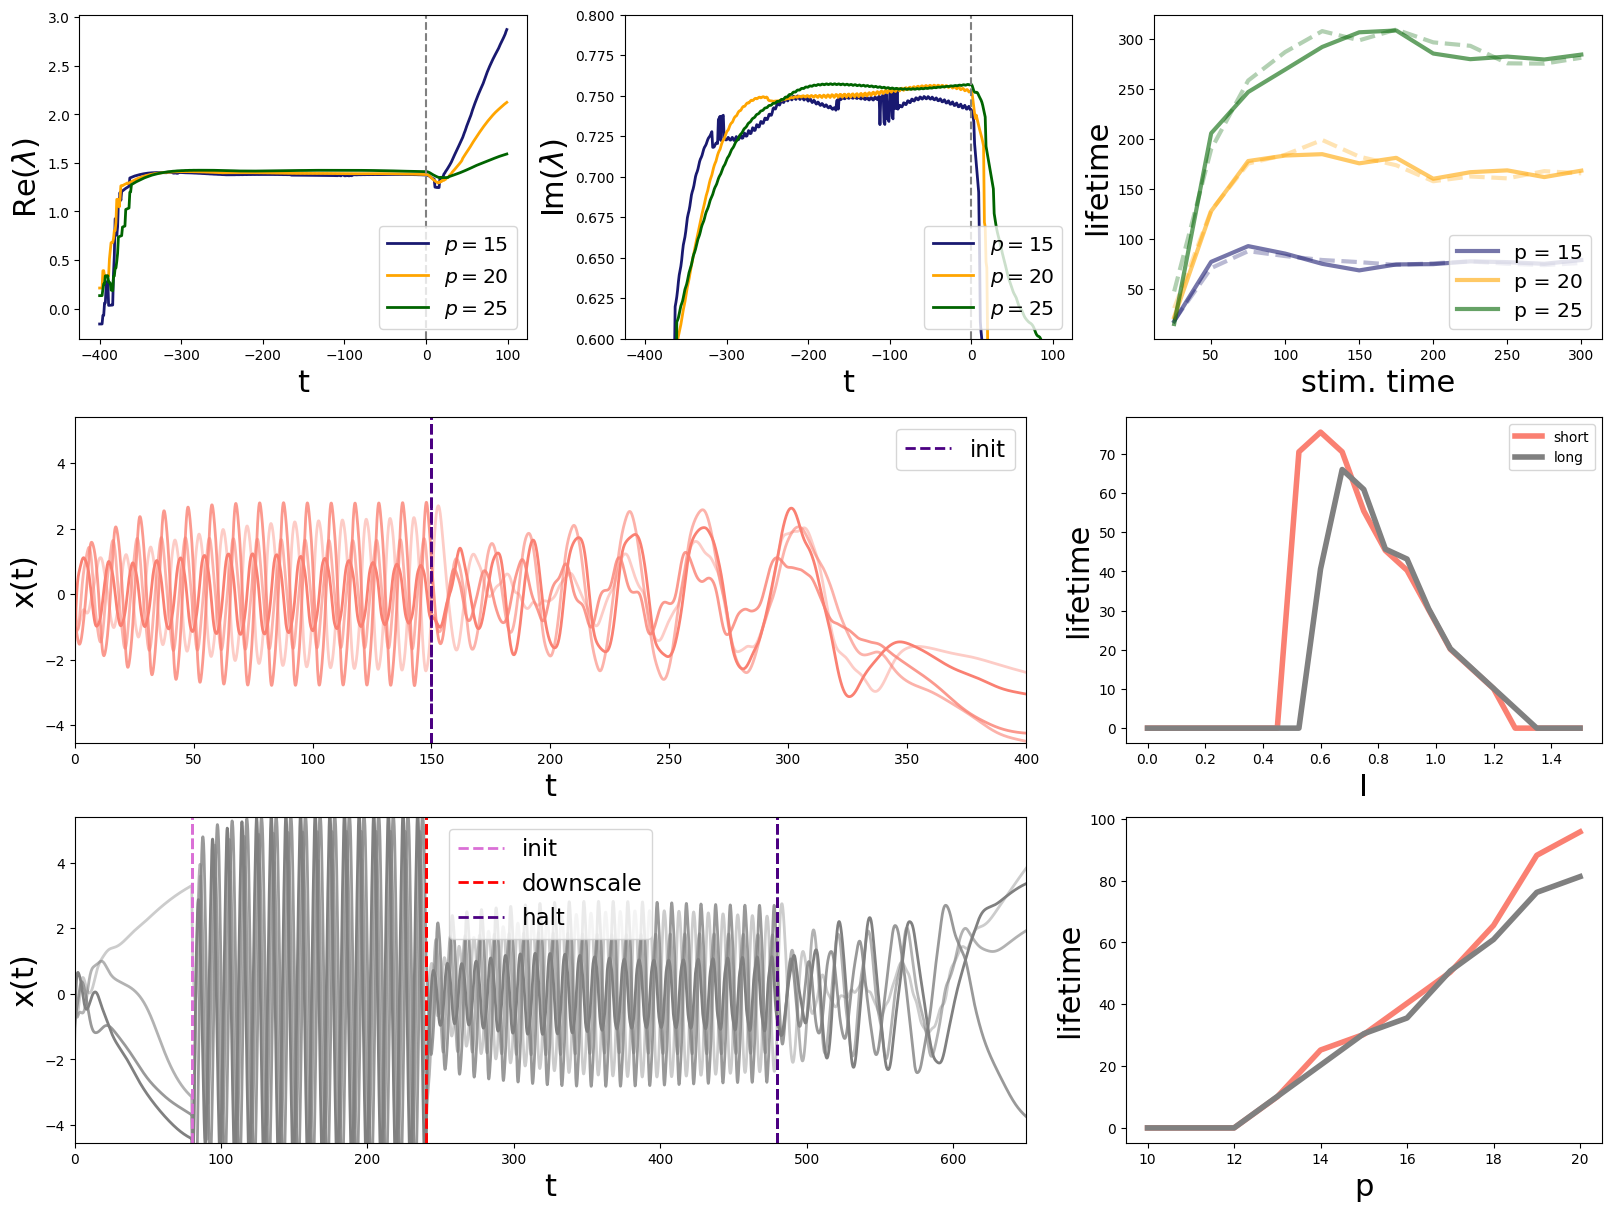

In [11]:
fig = plt.figure(layout='constrained', figsize=(16,12))
fn=22
fa, fb = fig.subfigures(nrows=2, height_ratios=[1,2]) 
aax = fa.subplots(ncols=3) 
bax = fb.subplots(nrows=2, ncols=2, width_ratios=[2,1])


make_top_row(path_eig, aax)
make_init_fig(bax)

fig.savefig(figdir + '/sm_figs/timing_fig.png', dpi=300, bbox_inches='tight')

## time resolution stuff

In [12]:
def get_n_dfs(path,load_rk=False):
    files = glob(path + '/k*.npy')
    res = defaultdict(dict) 
    dfs = []
    for j, f in tqdm(enumerate(files)): 
        if 'N_10000' in f: 
            print('p')
            continue 
        arr = np.load(f, allow_pickle=True).item()
        halt_time, T, dt_sim = arr['halt_time'], arr['T'], arr['dt']
        dt_actual = arr['dt'] 
        k, g, p, f, I = arr['k'], arr['g'], arr['p'], arr['f'], arr['I']
        N,p,I,k,f = arr['N'], arr['p'], arr['I'], arr['k'], arr['f']
        for i in range(arr['freqs_hi'].shape[0]): 
            oh = arr['freqs_hi'][i]
            lh = arr['life_hi'][i]
            ol = arr['freqs_lo'][i]
            ll = arr['life_lo'][i]
            lh = np.maximum(0, lh - T*halt_time)
            ll = np.maximum(0, ll - T*halt_time)
            df = pd.DataFrame({'T' : T, 'N' : N, 'p' : p, 'k' : k, 'I': I, 'f' : f, 
                               'life_hi' : lh, 'life_lo' : ll, 'om_hi' : oh, 'om_lo' : ol},
                              index=[0])
            dfs.append(df)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df['dt'] = dt_actual
    # mdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()
    mdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt', 'T']).mean().reset_index()
    sdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt', 'T']).std().reset_index()
    return df, mdf, sdf

In [13]:
dpath = outdir + '/scaling_sims/g_1.3_T_800_dt_0.5_scale_sanity_dt_check_sim'
ddf, dmdf, dsdf = get_n_dfs(dpath,load_rk=True) 

60it [00:11,  5.01it/s]


In [16]:
ddf.to_csv(outdir + '/scaling_sims/g_1.3_T_800_dt_0.5_scale_sanity_dt_check_sim/df.csv')

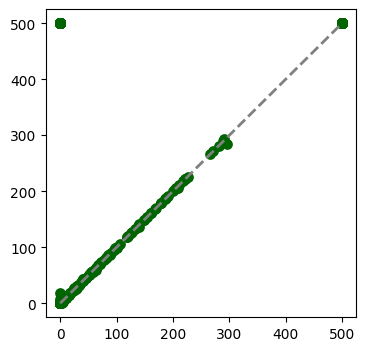

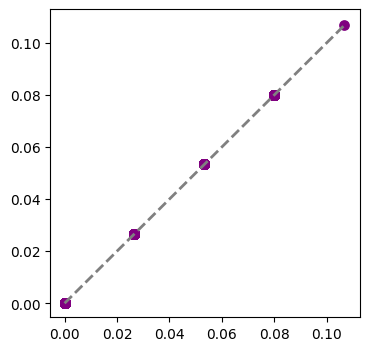

In [14]:
fn=22
lw=2
ms=45
fig,ax=plt.subplots(figsize=(4,4))


X = np.linspace(0,500,1000)
ax.plot(X,X, ls='--', color='grey',lw=lw)
ax.scatter(ddf.life_hi,
            ddf.life_lo, color='darkgreen',s=ms)
plt.show()
fig.savefig(figdir + '/sm_figs/dt_test_life.png', dpi=300,bbox_inches='tight')


fig,ax=plt.subplots(figsize=(4,4))
Y = np.linspace(0, 0.1075, 1000)
ax.plot(Y,Y, ls='--', color='grey',lw=lw)
ax.scatter(ddf.om_hi, ddf.om_lo, color='purple',s=ms)

fig.savefig(figdir + '/sm_figs/dt_test_freq.png', dpi=300,bbox_inches='tight')


In [15]:
reload(mf)
def eval_lifetime(path,fn=22,skip=50,b=0,eps=1e-1,w=400): 
    arr = np.load(path, allow_pickle=True).item()
    X = arr['Xh'][b]
    T, dt, halt_time = arr['T'], arr['dt'], arr['halt_time']
    # life=arr['life'][b]-T*halt_time
    life=mf.get_lifetime(X,T,dt,halt_time,eps=eps,w=w) - T*halt_time
    # print(life,life2)
    life=np.maximum(0, life)
    print("lifetime = ", life)
    print("freq. = ", arr['freqs'][b])
    print('freq dbl = ', mf.get_max_freq(X, T, halt_time, dt, eps=1e-2, window_size=100))
    print('freq dbl = ', mf.get_max_freq(X, T, halt_time, dt, eps=1e-3, window_size=37.5))
    psds = mf.sliding_psd(X, 400,skip) 
    print(psds.shape)
    print(mf.has_extrema(psds[-1],  eps=0))
    nt = psds.shape[0]
    fig,ax=plt.subplots(1,2,figsize=(16,5), width_ratios=[1, 2])
    tvec = np.linspace(0, T, int(T/dt))-T*halt_time
    colors=['teal', 'orange', 'red', 'grey', 'lightcoral']
    for a,i in enumerate(range(0, nt, nt//4)): 
        ax[0].loglog(psds[i], label=f"t = {round(tvec[i*skip],0)}",color=colors[a])
    ax[0].legend(fontsize=fn*2/3)
    for i in range(10): 
        ax[1].plot(tvec , X[:,i], color='midnightblue', alpha=(1+i) * 1/11)
    ylim=ax[1].get_ylim() 
    ax[1].vlines(life, *ylim, ls='--', label='lifetime')
    ax[1].legend(fontsize=fn*2/3)
    ax[1].set_ylim(ylim)

    ax[0].set_xlabel("freq.", fontsize=fn)
    ax[0].set_ylabel("power",fontsize=fn)
    ax[1].set_xlabel("t",fontsize=fn)
    ax[1].set_ylabel("x(t)",fontsize=fn)
    return fig, ax 

lifetime =  178.73574714942993
freq. =  0.08
freq dbl =  0.05
freq dbl =  0.08
(133, 200)
True


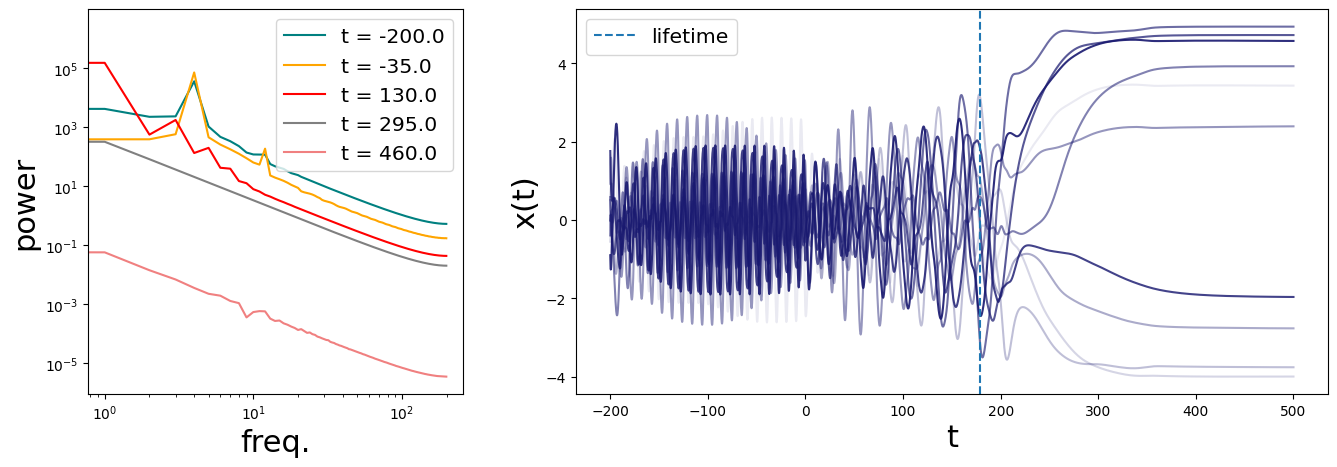

In [16]:
b=5
I=0.5
p=20
path = outdir + f'/scaling_sims/g_1.3_dt_0.1_scale_p_sim/k_3.0_g_1.3_I_{I}_p_25.0_N_1000_f_0.1_T_700_halt_0.285714_rep_0_comparison.npy'
fig, ax=eval_lifetime(path, b=2)
fig.savefig(figdir + '/sm_figs/example_lifetime_eval.png', dpi=300,bbox_inches='tight')